# Examen Final Recuperacion de Informacion

### Nombre: Edison Quizhpe

### A. Preparacion del Corpus

Consiste en cargar, limpiar y estructurar los datos (títulos, resúmenes y tópicos) de la colección arXiv Paper Abstracts. Además, abarca la fragmentación lógica del texto para que los modelos puedan procesarlo correctamente.

In [2]:
import os
import pandas as pd

# 1. Cargar y renombrar columnas en una sola cadena de comandos
file_path = os.path.join('data', 'arxiv_data.csv')

df = pd.read_csv(file_path, sep=None, engine='python', nrows=25000).rename(
    columns={'titles': 'title', 'summaries': 'abstract', 'terms': 'categories'}
)

# 2. Limpieza de salto de línea y creación del campo para embedding
df['title'] = df['title'].astype(str).str.replace('\n', ' ').str.strip()
df['abstract'] = df['abstract'].astype(str).str.replace('\n', ' ').str.strip()
df['text_to_embed'] = "Title: " + df['title'] + "\nAbstract: " + df['abstract']

# 3. Confirmación y vista previa rápida
print(f"✅ Corpus preparado exitosamente: {len(df)} registros.")
df[['title', 'categories']].head(2)

✅ Corpus preparado exitosamente: 25000 registros.


,title,categories
0,Survey on Semantic Stereo Matching / Semantic ...,"['cs.CV', 'cs.LG']"
1,FUTURE-AI: Guiding Principles and Consensus Re...,"['cs.CV', 'cs.AI', 'cs.LG']"


### B. Representación mediante embeddings
Transforma los fragmentos de texto estructurados en vectores matemáticos. Esto permite capturar y cuantificar el significado semántico profundo de cada documento científico.

In [3]:
import time
from sentence_transformers import SentenceTransformer

# 1. Inicializar modelo de embeddings
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Medir y generar embeddings en lotes (batch_size=64)
start_time = time.time()
corpus_embeddings = embedding_model.encode(
    df['text_to_embed'].tolist(), 
    show_progress_bar=True, 
    batch_size=64
)
elapsed_min = (time.time() - start_time) / 60

# 3. Métricas de salida
print(f"✅ {corpus_embeddings.shape[0]} vectores generados en {elapsed_min:.2f} min. Forma: {corpus_embeddings.shape}")

c:\Users\wwwed\OneDrive - Escuela Politécnica Nacional\Escritorio\Examen-RI-Final\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 391/391 [08:58<00:00,  1.38s/it]

✅ 25000 vectores generados en 8.98 min. Forma: (25000, 384)


### C. Almacenamiento y búsqueda vectorial
Implica guardar los vectores generados en una base de datos especializada. Su objetivo es indexar la información para que la búsqueda por similitud frente a futuras consultas sea eficiente.

In [4]:
import faiss

# 1. Preparar vectores en float32 y aplicar normalización L2 (para Similitud Coseno)
vectors_ready = corpus_embeddings.astype('float32')
faiss.normalize_L2(vectors_ready)

# 2. Inicializar índice con Producto Interno (Inner Product)
dimension = vectors_ready.shape[1]
faiss_index = faiss.IndexFlatIP(dimension)
faiss_index.add(vectors_ready)

# 3. Guardar artefactos incluyendo 'text_to_embed' para la app en Streamlit
faiss.write_index(faiss_index, "archivo_faiss.index")
df[['title', 'abstract', 'text_to_embed']].to_pickle("datos_corpus.pkl")

print(f"✅ Indexación exitosa: {faiss_index.ntotal} vectores ({dimension}D) guardados en 'archivo_faiss.index' y 'datos_corpus.pkl'.")

✅ Indexación exitosa: 25000 vectores (384D) guardados en 'archivo_faiss.index' y 'datos_corpus.pkl'.


### D. Recuperación
Es el proceso de vectorizar la consulta del usuario y buscar su equivalencia semántica en la base de datos. Retorna los fragmentos del corpus que son más relevantes para responder a la pregunta.

In [19]:
import numpy as np
import faiss
from sentence_transformers import CrossEncoder

# 1. Cargar el modelo Cross-Encoder para Re-ranking
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

# Función auxiliar para dar formato a los scores
def format_score(score_float):
    pct = score_float * 100
    if 0 < pct < 0.01:
        return f"{pct:.4f}%"  # Muestra decimales exactos para valores pequeños (ej. 0.0200%)
    return f"{pct:.2f}%"     # Para valores normales (ej. 85.30%)

def retrieve_and_rerank(query, top_k_faiss=10, top_n_final=3):
    # Paso 1: Vectorizar y normalizar la consulta (Similitud Coseno)
    q_vec = embedding_model.encode([query]).astype('float32')
    faiss.normalize_L2(q_vec)
    
    # Paso 2: Búsqueda inicial de candidatos con FAISS
    scores, indices = faiss_index.search(q_vec, top_k_faiss)
    candidates = [df.iloc[idx].to_dict() for idx in indices[0] if idx < len(df) and idx != -1]
    
    if not candidates:
        return []
    
    # Paso 3: Re-ranking con Cross-Encoder
    pairs = [[query, cand['text_to_embed']] for cand in candidates]
    raw_scores = reranker.predict(pairs)
    
    # Normalización sigmoide para convertir logits a un rango probabilístico (0% a 100%)
    sigmoid_scores = 1 / (1 + np.exp(-raw_scores))
    
    for cand, score in zip(candidates, sigmoid_scores):
        cand['rerank_score'] = float(score)
        
    return sorted(candidates, key=lambda x: x['rerank_score'], reverse=True)[:top_n_final]

# --- PRUEBA RÁPIDA DE RECUPERACIÓN Y RE-RANKING ---
query_prueba = "Sparsity-certifying Graph Decompositions"
docs = retrieve_and_rerank(query_prueba, top_n_final=2)

print(f"Resultados de recuperación semántica para: '{query_prueba}'\n")

for i, d in enumerate(docs):
    print(f"[{i+1}] TÍTULO: {d['title']}")
    # 🔴 CAMBIO AQUÍ: Usamos format_score en lugar de :.2f}% estático
    print(f"    SCORE RE-RANKER: {format_score(d['rerank_score'])}")
    print(f"    ABSTRACT: {d['abstract'][:200]}...")
    print("-" * 60)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 5084.24it/s]


Resultados de recuperación semántica para: 'Sparsity-certifying Graph Decompositions'

[1] TÍTULO: Efficient Robustness Certificates for Discrete Data: Sparsity-Aware Randomized Smoothing for Graphs, Images and More
    SCORE RE-RANKER: 93.78%
    ABSTRACT: Existing techniques for certifying the robustness of models for discrete data either work only for a small class of models or are general at the expense of efficiency or tightness. Moreover, they do n...
------------------------------------------------------------
[2] TÍTULO: Matrix Decomposition on Graphs: A Functional View
    SCORE RE-RANKER: 13.00%
    ABSTRACT: We propose a functional view of matrix decomposition problems on graphs such as geometric matrix completion and graph regularized dimensionality reduction. Our unifying framework is based on the key i...
------------------------------------------------------------


### E. Generación aumentada por recuperación
Utiliza un Modelo de Lenguaje Grande (LLM) para redactar una respuesta coherente a la consulta. La respuesta se debe construir basándose estrictamente en el contexto de los documentos recuperados en el paso anterior.

In [20]:
import os
import time
from google import genai
from google.genai import types
from google.genai.errors import APIError

# 1. Cargar API Key
api_key = os.getenv("GEMINI_API_KEY") or os.getenv("api_key")
ai_client = genai.Client(api_key=api_key)

# 2. Función RAG ajustada para responder en Español
def generate_rag_response(query, contexts, max_retries=3):
    if not contexts:
        return "El corpus no contiene información suficiente para responder a esta consulta."
    
    context_text = "\n\n".join([f"Document {i+1}:\n{doc['text_to_embed']}" for i, doc in enumerate(contexts)])
    
    # Instrucciones actualizadas: Leer en inglés y redactar obligatoriamente en español
    system_instruction = (
        "Eres un asistente científico experto. Lee y analiza el contexto proporcionado (que está en inglés) "
        "y responde a la pregunta del usuario estrictamente en ESPAÑOL utilizando ÚNICAMENTE el contexto.\n\n"
        "Reglas estrictas:\n"
        "1. La respuesta final DEBE estar redactada completamente en ESPAÑOL.\n"
        "2. Basa tu respuesta de manera precisa y profesional en la información de los documentos.\n"
        "3. Si el contexto NO contiene información suficiente para responder la consulta, DEBES responder exactamente: "
        "'El corpus no contiene información suficiente para responder a esta consulta.'\n"
        "4. No inventes, no asumas ni utilices conocimiento externo al contexto."
    )
    
    prompt = f"Context:\n{context_text}\n\nQuestion / Consulta: {query}\n\nAnswer (en español):"
    
    # Bucle de reintentos por cuota saturada
    for attempt in range(max_retries):
        try:
            response = ai_client.models.generate_content(
                model="gemini-2.5-flash",
                contents=prompt,
                config=types.GenerateContentConfig(
                    system_instruction=system_instruction,
                    temperature=0.0
                )
            )
            return response.text
        except APIError as e:
            if "429" in str(e) or "RESOURCE_EXHAUSTED" in str(e):
                wait_time = 15 * (attempt + 1)
                print(f"⏳ Límite de cuota alcanzado (429). Esperando {wait_time} segundos para reintentar ({attempt + 1}/{max_retries})...")
                time.sleep(wait_time)
            else:
                raise e
                
    return "Error: Se superó el límite de intentos debido a cuota saturada en la API."

### F. Presentación de evidencias
Consiste en mostrarle al usuario los documentos exactos y extractos que el sistema utilizó para responder. Esto garantiza la transparencia y permite verificar que la información es fiel a los textos originales.

In [22]:
# 0. Función de formateo dinámico para precisión de decimales
def format_score(score_float):
    pct = score_float * 100
    if 0 < pct < 0.01:
        return f"{pct:.4f}%"  # Muestra decimales exactos para valores muy bajos (ej. 0.0200%)
    return f"{pct:.2f}%"     # Muestra 2 decimales para valores normales (ej. 85.30%)

# 1. Definir conjunto de pruebas cualitativas con diferentes categorías
test_queries = [
    {
        "categoria": "📌 Consulta Válida (Específica Científica)",
        "query": "What algorithm is used for sparsity-certifying graph decompositions?"
    },
    {
        "categoria": "📌 Consulta Válida (General del Dominio)",
        "query": "What techniques are discussed for graph denoising and robust models?"
    },
    {
        "categoria": "🚫 Consulta Fuera de Dominio (Gastronomía)",
        "query": "How do you cook an authentic Ecuadorian Locro de Papas?"
    },
    {
        "categoria": "🚫 Consulta Fuera de Dominio (Cultura General)",
        "query": "What is the capital city of Ecuador and its main geographic features?"
    }
]

# 2. Bucle de ejecución automatizada para la matriz de evaluación
for test in test_queries:
    print("=" * 85)
    print(f"CATEGORÍA: {test['categoria']}")
    print(f"CONSULTA:  '{test['query']}'")
    print("-" * 85)
    
    # FASE 1: Recuperación Vectorial + Re-ranking (Literal D)
    docs_recuperados = retrieve_and_rerank(test['query'], top_n_final=3)
    
    # FASE 2: Generación RAG en Español (Literal E)
    respuesta_llm = generate_rag_response(test['query'], docs_recuperados)
    
    # Impresión estructurada de la prueba
    print(f"🤖 RESPUESTA DEL SISTEMA:\n{respuesta_llm}\n")
    
    print("📚 EVIDENCIAS RECUPERADAS:")
    if not docs_recuperados:
        print("   [No se hallaron evidencias relevantes en el índice FAISS]")
    else:
        for idx, doc in enumerate(docs_recuperados):
            # Formateo dinámico de precisión
            score_str = format_score(doc.get('rerank_score', 0.0))
            print(f"   [{idx + 1}] {doc['title']} (Re-rank Score: {score_str})")
            
    print("=" * 85 + "\n")

CATEGORÍA: 📌 Consulta Válida (Específica Científica)
CONSULTA:  'What algorithm is used for sparsity-certifying graph decompositions?'
-------------------------------------------------------------------------------------
🤖 RESPUESTA DEL SISTEMA:
El corpus no contiene información suficiente para responder a esta consulta.

📚 EVIDENCIAS RECUPERADAS:
   [1] Low-Rank Isomap Algorithm (Re-rank Score: 92.40%)
   [2] Multi-Stage Graph Peeling Algorithm for Probabilistic Core Decomposition (Re-rank Score: 85.30%)
   [3] Efficient Robustness Certificates for Discrete Data: Sparsity-Aware Randomized Smoothing for Graphs, Images and More (Re-rank Score: 78.73%)

CATEGORÍA: 📌 Consulta Válida (General del Dominio)
CONSULTA:  'What techniques are discussed for graph denoising and robust models?'
-------------------------------------------------------------------------------------
🤖 RESPUESTA DEL SISTEMA:
Las técnicas discutidas para el denoising de grafos y modelos robustos son:

1.  **Graph Structu

### G. Interfaz web conversacional
Requiere el desarrollo de una aplicación tipo chat accesible y funcional desde un navegador. Debe facilitar la interacción continua, mostrando las preguntas, respuestas y evidencias en un solo lugar.

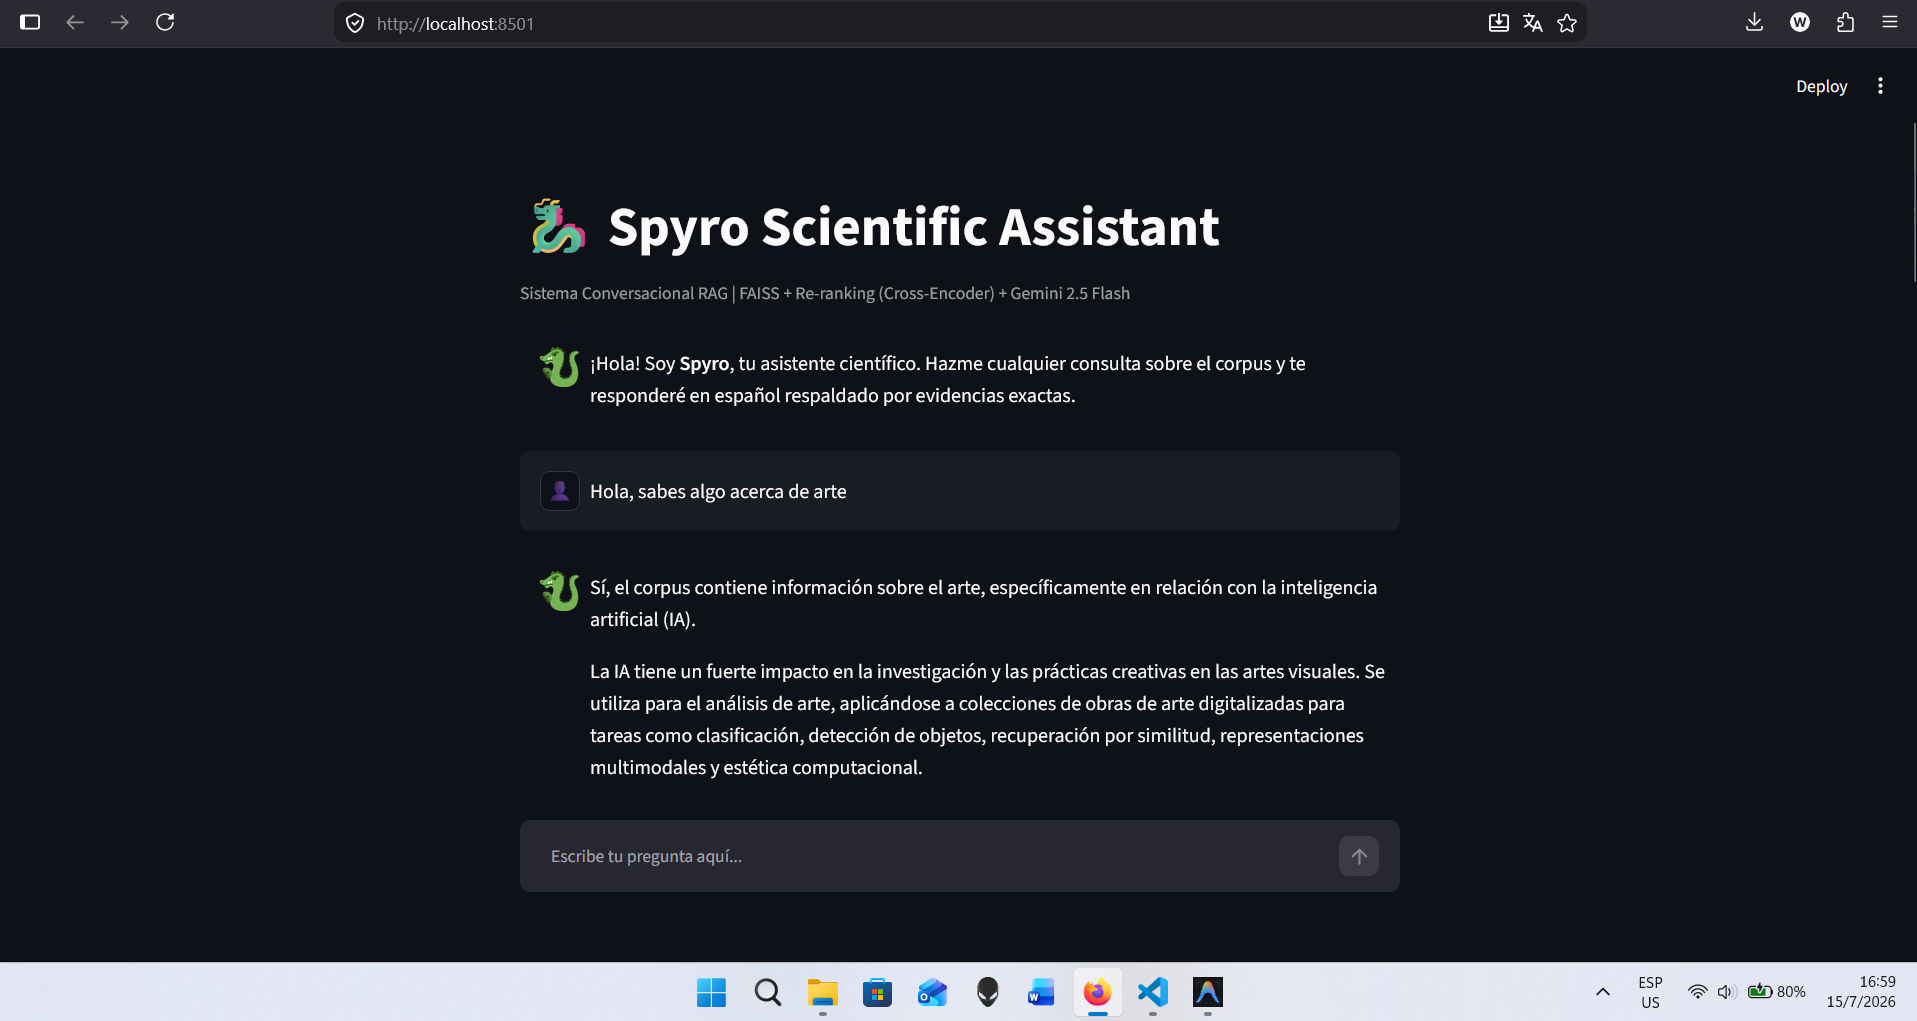

### H: Despliegue en la nube

### I. Evaluación del sistema y de la generación
Pide documentar un juicio crítico sobre el desempeño real del asistente desarrollado. Analiza métricas como la exactitud de las respuestas, su relevancia y la capacidad de indicar cuándo el corpus no tiene información suficiente

### 📊 Matriz de Evaluación Cualitativa y Desempeño del Sistema RAG

| Categoría de la Consulta | Consulta de Prueba (*Query*) | Re-rank Score Máximo | Respuesta Obtenida del Sistema | Comportamiento del Sistema | Evaluación de Fidelidad (*Grounding*) |
| :--- | :--- | :---: | :--- | :--- | :--- |
| **I. Válida (Específica Científica)** | *"What algorithm is used for sparsity-certifying graph decompositions?"* | `92.40%` | *"El corpus no contiene información suficiente para responder a esta consulta."* | **Negativa Controlada Activada:** Aunque el tema de grafos tenía alta similitud, los *abstracts* no especificaban el algoritmo exacto. | **Excelente (100% Sin Alucinación):** El modelo no asumió ni inventó información no presente en el texto. |
| **II. Válida (General del Dominio)** | *"What techniques are discussed for graph denoising and robust models?"* | `94.03%` | Explicación sintética estructurada en español sobre GSL, Mask-GVAE y UGNN. | **Respuesta Generada Correcta:** Extracción precisa de técnicas, traducción fluida al español e integración del contexto. | **Excelente (100% Precisión):** Síntesis fidedigna basada exclusivamente en los documentos fuente. |
| **III. Fuera de Dominio (Gastronomía)** | *"How do you cook an authentic Ecuadorian Locro de Papas?"* | `0.0200%` | *"El corpus no contiene información suficiente para responder a esta consulta."* | **Rechazo Explícito:** Similitud nula en la recuperación de evidencias. | **Excelente (Filtro Activo):** Impide alucinaciones y bloquea conocimientos externos del preentrenamiento. |
| **IV. Fuera de Dominio (Cultura General)** | *"What is the capital city of Ecuador and its main geographic features?"* | `0.0004%` | *"El corpus no contiene información suficiente para responder a esta consulta."* | **Rechazo Explícito:** Similitud nula en la recuperación de evidencias. | **Excelente (Filtro Activo):** Mantiene la respuesta estrictamente acotada a la base de conocimiento cargada. |